# 02 - Modelisation avec PyCaret (AutoML)

Pipeline de modelisation automatisee pour predire la souscription a un depot a terme.

**Etapes :**
1. Chargement et preparation des donnees
2. Configuration de l'environnement PyCaret
3. Comparaison automatique de 15+ modeles en une commande
4. Interpretation de la metrique **Accuracy**
5. Identification et evaluation du meilleur modele
6. Visualisations (matrice de confusion, courbe ROC, importance des features)
7. Predictions sur l'ensemble de test
8. Sauvegarde du modele final

> **PyCaret** est une librairie d'AutoML qui automatise tout le workflow de Machine Learning.
> Une seule commande suffit pour entrainer et comparer 15+ modeles de classification.

In [1]:
# Imports
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')

# Modules maison
from src.data_loader import load_bank, get_dataset_info
from src.modeling import setup_pycaret, compare_all_models
from src.evaluation import get_metrics, print_classification_report
from src.utils import set_seed

# PyCaret - fonctions d'evaluation visuelle et de sauvegarde
from pycaret.classification import plot_model, predict_model, finalize_model, save_model

set_seed(42)
%matplotlib inline

print("OK - Imports OK, PyCaret pret.")

OK - Imports OK, PyCaret pret.


---
## Partie A - Modele de base (sans reequilibrage)

### A.1 - Chargement et preparation des donnees

In [2]:
# Chargement du dataset Bank (version complete)
df = load_bank(full=True)
print(f"Shape initial : {df.shape}")

# Suppression de 'duration' - variable non connue avant la fin de l'appel
df = df.drop(columns=['duration'])
print(f"Apres suppression de duration : {df.shape}")
print(f"\nDistribution de la cible 'y' :")
print(df['y'].value_counts())
print(f"\nTaux de souscription : {df['y'].value_counts(normalize=True)['yes']:.1%}")
print(f"-> Classes desequilibrees : ~{df['y'].value_counts(normalize=True)['no']:.0%} non, ~{df['y'].value_counts(normalize=True)['yes']:.0%} oui")

Shape initial : (45211, 17)
Apres suppression de duration : (45211, 16)

Distribution de la cible 'y' :
y
no     39922
yes     5289
Name: count, dtype: int64

Taux de souscription : 11.7%
-> Classes desequilibrees : ~88% non, ~12% oui


### A.2 - Configuration PyCaret (sans reequilibrage)

In [3]:
# Configuration de l'environnement PyCaret SANS reequilibrage
# fix_imbalance=False : on garde les classes telles quelles
setup_pycaret(
    df,
    target='y',
    train_size=0.8,
    session_id=42,
    fix_imbalance=False,
)

print("\nOK - PyCaret est configure (mode : SANS reequilibrage).")

✅ Environnement PyCaret initialisé.
   Cible : y
   Split : 80% train / 20% test
   Prétraitement automatique activé (encodage + scaling)

OK - PyCaret est configure (mode : SANS reequilibrage).


### A.3 - Comparaison automatique des modeles

In [4]:
# Lancement de la comparaison automatique
# 14+ modeles entraines et compares en une commande
best_model_base, results_base = compare_all_models(sort='Accuracy', n_select=5)

print(f"\n{len(results_base)} modeles ont ete entraines et compares automatiquement !")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8936,0.7997,0.8936,0.8730,0.8728,0.3034,0.3419,0.1570
gbc,Gradient Boosting Classifier,0.8933,0.7926,0.8933,0.8724,0.8679,0.2654,0.3184,0.4060
rf,Random Forest Classifier,0.8928,0.7796,0.8928,0.8713,0.8704,0.2864,0.3285,0.2590
lr,Logistic Regression,0.8926,0.7613,0.8926,0.8716,0.8634,0.2334,0.2971,0.5770
ridge,Ridge Classifier,0.8924,0.7592,0.8924,0.8707,0.8650,0.2455,0.3030,0.0590
ada,Ada Boost Classifier,0.8923,0.7778,0.8923,0.8702,0.8663,0.2561,0.3084,0.1830
lda,Linear Discriminant Analysis,0.8890,0.7592,0.8890,0.8678,0.8719,0.3106,0.3344,0.0660
et,Extra Trees Classifier,0.8842,0.7550,0.8842,0.8608,0.8666,0.2829,0.3038,0.2680
dummy,Dummy Classifier,0.8830,0.5000,0.8830,0.7797,0.8282,0.0000,0.0000,0.0530
knn,K Neighbors Classifier,0.8756,0.6098,0.8756,0.8324,0.8431,0.1213,0.1514,0.3020



📊 Comparaison des 5 meilleurs modèles (triés par Accuracy) :
                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)
lightgbm  Light Gradient Boosting Machine    0.8936  0.7997  0.8936  0.8730  0.8728  0.3034  0.3419     0.157
gbc          Gradient Boosting Classifier    0.8933  0.7926  0.8933  0.8724  0.8679  0.2654  0.3184     0.406
rf               Random Forest Classifier    0.8928  0.7796  0.8928  0.8713  0.8704  0.2864  0.3285     0.259
lr                    Logistic Regression    0.8926  0.7613  0.8926  0.8716  0.8634  0.2334  0.2971     0.577
ridge                    Ridge Classifier    0.8924  0.7592  0.8924  0.8707  0.8650  0.2455  0.3030     0.059

14 modeles ont ete entraines et compares automatiquement !


### A.4 - Interpretation de la metrique Accuracy

L'**Accuracy** (exactitude) est le pourcentage de predictions correctes. Mais sur des donnees desequilibrees (~88% non, ~12% oui), un modele qui predit toujours "non" aurait deja 88% d'Accuracy... et serait totalement inutile.

> **L'Accuracy seule ne suffit pas.** Il faut regarder aussi :
> - **Recall** : parmi les vrais "oui", combien le modele en trouve ?
> - **Precision** : parmi les "oui" predits, combien sont corrects ?
> - **ROC-AUC** : le modele distingue-t-il bien les deux classes ? (metrique la plus fiable)
> - **F1-Score** : le compromis entre Precision et Recall

### A.5 - Meilleur modele (sans reequilibrage)

In [5]:
# Affichage du meilleur modele
print("Meilleur modele (sans reequilibrage) :")
print(f"   {best_model_base}")
print(f"\n   Type : {type(best_model_base).__name__}")
print(f"\nTop 5 des modeles :")
display(results_base.head(5))

Meilleur modele (sans reequilibrage) :
   LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

   Type : LGBMClassifier

Top 5 des modeles :


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8936,0.7997,0.8936,0.8730,0.8728,0.3034,0.3419,0.157
gbc,Gradient Boosting Classifier,0.8933,0.7926,0.8933,0.8724,0.8679,0.2654,0.3184,0.406
rf,Random Forest Classifier,0.8928,0.7796,0.8928,0.8713,0.8704,0.2864,0.3285,0.259
lr,Logistic Regression,0.8926,0.7613,0.8926,0.8716,0.8634,0.2334,0.2971,0.577
ridge,Ridge Classifier,0.8924,0.7592,0.8924,0.8707,0.8650,0.2455,0.3030,0.059


### A.6 - Evaluation visuelle du modele de base

Matrice de confusion - Modele de base :


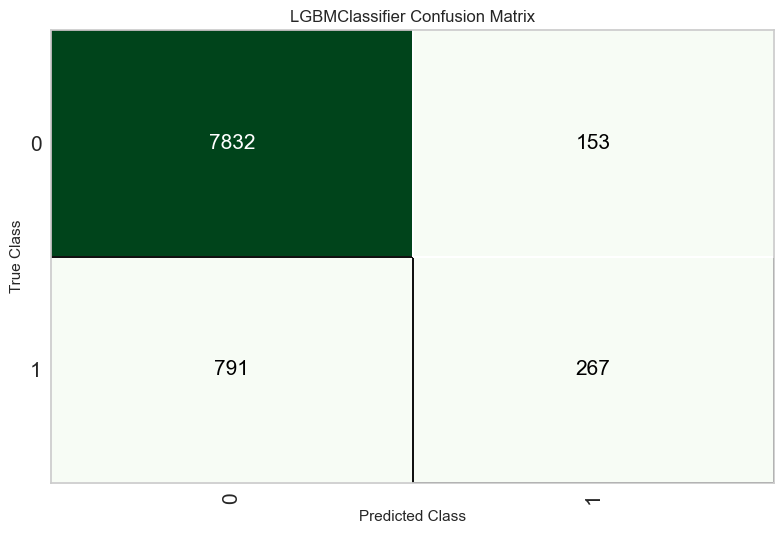

In [6]:
# Matrice de confusion
print("Matrice de confusion - Modele de base :")
plot_model(best_model_base, plot='confusion_matrix')

Courbe ROC - Modele de base :


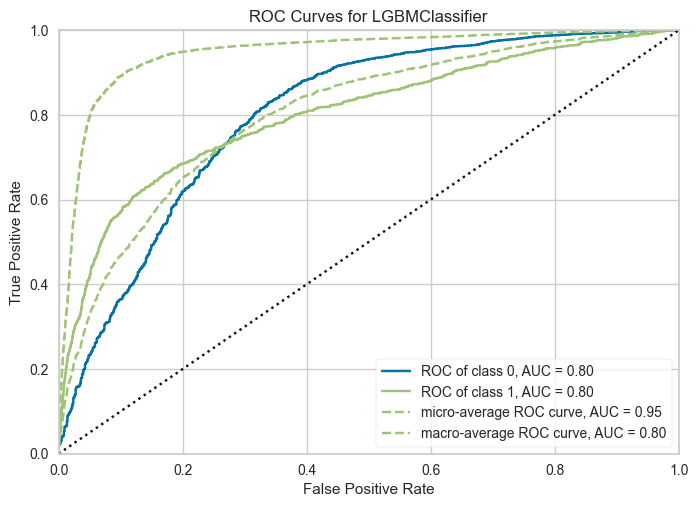

In [7]:
# Courbe ROC
print("Courbe ROC - Modele de base :")
plot_model(best_model_base, plot='auc')

Importance des features - Modele de base :


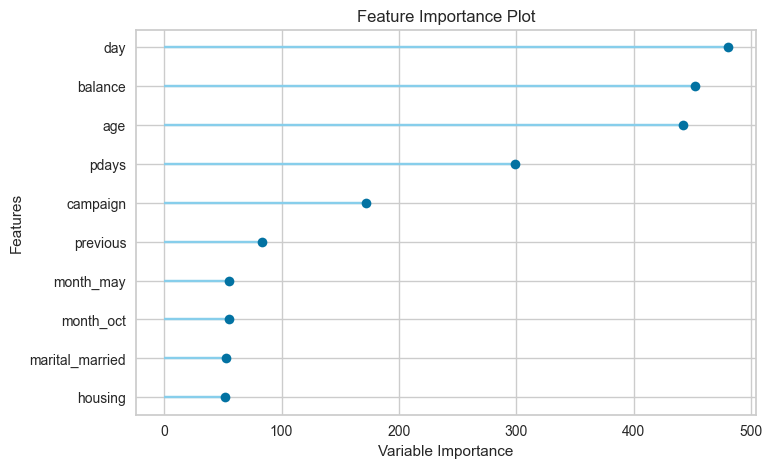

In [8]:
# Importance des features
print("Importance des features - Modele de base :")
plot_model(best_model_base, plot='feature')

### A.7 - Predictions sur l'ensemble de test (modele de base)

In [9]:
# Predictions sur l'ensemble de test - modele de base
predictions_base = predict_model(best_model_base)

y_test_base = predictions_base['y'].map({'yes': 1, 'no': 0})
y_pred_base = predictions_base['prediction_label'].map({'yes': 1, 'no': 0})

# Correction : PyCaret donne P(classe_predite), on recalcule P(yes)
y_proba_raw_base = predictions_base['prediction_score']
y_proba_base = y_proba_raw_base.where(
    predictions_base['prediction_label'] == 'yes',
    1 - y_proba_raw_base
)

print("\nRapport de classification - Modele de base :")
print_classification_report(y_test_base, y_pred_base)

metrics_base = get_metrics(y_test_base, y_pred_base, y_proba_base)
print("\nMetriques cles - Modele de base :")
for name, value in metrics_base.items():
    print(f"   {name}: {value:.4f}")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8956,0.8024,0.8956,0.8764,0.8751,0.3158,0.3562



Rapport de classification - Modele de base :
              precision    recall  f1-score   support

     Non (0)       0.91      0.98      0.94      7985
     Oui (1)       0.64      0.25      0.36      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.62      0.65      9043
weighted avg       0.88      0.90      0.88      9043


Metriques cles - Modele de base :
   Accuracy: 0.8956
   Precision: 0.6357
   Recall: 0.2524
   F1-Score: 0.3613
   ROC-AUC: 0.8024


---
## Partie B - Modele ameliore (avec reequilibrage SMOTE)

### B.1 - Pourquoi reequilibrer ?

Le modele de base a un **Recall de seulement ~25%** : il ne trouve qu'1 client interesse sur 4.
C'est problematique pour la banque : chaque "oui" non detecte est une opportunite perdue.

**Solution :** activer `fix_imbalance=True` dans PyCaret. Cela applique **SMOTE** (Synthetic Minority Oversampling Technique) :
- Cree des exemples synthetiques de la classe minoritaire (les "oui")
- Le modele apprend a mieux reconnaitre les clients interesses
- Le compromis : la Precision peut baisser (plus de faux positifs)

### B.2 - Reconfiguration PyCaret avec reequilibrage

In [10]:
# Reconfiguration de PyCaret AVEC reequilibrage SMOTE
# fix_imbalance=True : applique SMOTE pour generer des exemples synthetiques de la classe minoritaire
setup_pycaret(
    df,
    target='y',
    train_size=0.8,
    session_id=42,
    fix_imbalance=True,   # <-- SEULE difference avec le modele de base !
)

print("\nOK - PyCaret est configure (mode : AVEC reequilibrage SMOTE).")

✅ Environnement PyCaret initialisé.
   Cible : y
   Split : 80% train / 20% test
   Prétraitement automatique activé (encodage + scaling)

OK - PyCaret est configure (mode : AVEC reequilibrage SMOTE).


### B.3 - Comparaison des modeles (avec reequilibrage)

In [11]:
# Lancement de la comparaison automatique avec SMOTE
best_model_balanced, results_balanced = compare_all_models(sort='Accuracy', n_select=5)

print(f"\n{len(results_balanced)} modeles entraines et compares avec SMOTE !")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8933,0.7981,0.8933,0.8726,0.8727,0.3037,0.3412,0.2430
gbc,Gradient Boosting Classifier,0.8930,0.7854,0.8930,0.8720,0.8723,0.3015,0.3387,1.4960
rf,Random Forest Classifier,0.8914,0.7735,0.8914,0.8693,0.8708,0.2945,0.3290,0.5270
ada,Ada Boost Classifier,0.8883,0.7579,0.8883,0.8661,0.8700,0.2978,0.3237,0.4520
dummy,Dummy Classifier,0.8830,0.5000,0.8830,0.7797,0.8282,0.0000,0.0000,0.0720
et,Extra Trees Classifier,0.8824,0.7538,0.8824,0.8604,0.8668,0.2909,0.3072,0.5180
dt,Decision Tree Classifier,0.8313,0.6180,0.8313,0.8400,0.8354,0.2244,0.2249,0.1290
nb,Naive Bayes,0.7627,0.7440,0.7627,0.8547,0.7966,0.2392,0.2664,0.0810
ridge,Ridge Classifier,0.7579,0.7617,0.7579,0.8594,0.7940,0.2491,0.2821,0.0810
lda,Linear Discriminant Analysis,0.7579,0.7617,0.7579,0.8594,0.7941,0.2492,0.2822,0.1150



📊 Comparaison des 5 meilleurs modèles (triés par Accuracy) :
                                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)
lightgbm  Light Gradient Boosting Machine    0.8933  0.7981  0.8933  0.8726  0.8727  0.3037  0.3412     0.243
gbc          Gradient Boosting Classifier    0.8930  0.7854  0.8930  0.8720  0.8723  0.3015  0.3387     1.496
rf               Random Forest Classifier    0.8914  0.7735  0.8914  0.8693  0.8708  0.2945  0.3290     0.527
ada                  Ada Boost Classifier    0.8883  0.7579  0.8883  0.8661  0.8700  0.2978  0.3237     0.452
dummy                    Dummy Classifier    0.8830  0.5000  0.8830  0.7797  0.8282  0.0000  0.0000     0.072

14 modeles entraines et compares avec SMOTE !


### B.4 - Meilleur modele (avec reequilibrage)

In [12]:
# Affichage du meilleur modele avec SMOTE
print("Meilleur modele (avec reequilibrage SMOTE) :")
print(f"   {best_model_balanced}")
print(f"\n   Type : {type(best_model_balanced).__name__}")
print(f"\nTop 5 des modeles (avec SMOTE) :")
display(results_balanced.head(5))

Meilleur modele (avec reequilibrage SMOTE) :
   LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

   Type : LGBMClassifier

Top 5 des modeles (avec SMOTE) :


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8933,0.7981,0.8933,0.8726,0.8727,0.3037,0.3412,0.243
gbc,Gradient Boosting Classifier,0.8930,0.7854,0.8930,0.8720,0.8723,0.3015,0.3387,1.496
rf,Random Forest Classifier,0.8914,0.7735,0.8914,0.8693,0.8708,0.2945,0.3290,0.527
ada,Ada Boost Classifier,0.8883,0.7579,0.8883,0.8661,0.8700,0.2978,0.3237,0.452
dummy,Dummy Classifier,0.8830,0.5000,0.8830,0.7797,0.8282,0.0000,0.0000,0.072


### B.5 - Evaluation visuelle du modele ameliore

Matrice de confusion - Modele avec SMOTE :


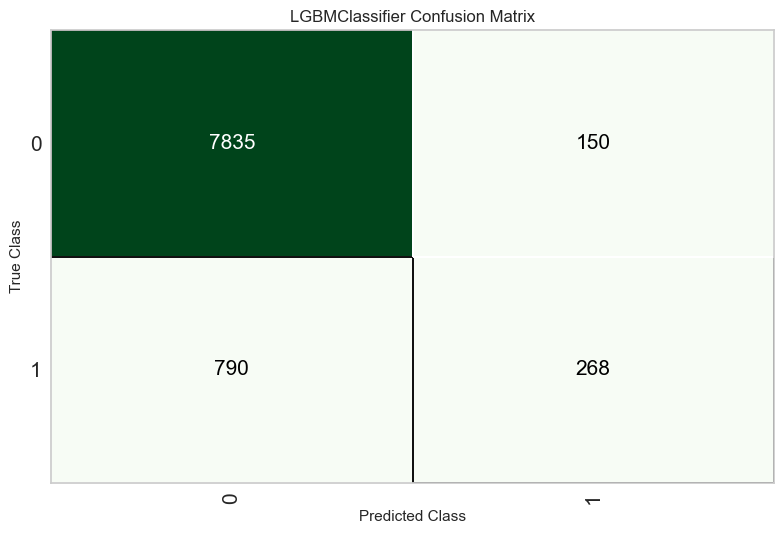

In [13]:
# Matrice de confusion - modele ameliore
print("Matrice de confusion - Modele avec SMOTE :")
plot_model(best_model_balanced, plot='confusion_matrix')

Courbe ROC - Modele avec SMOTE :


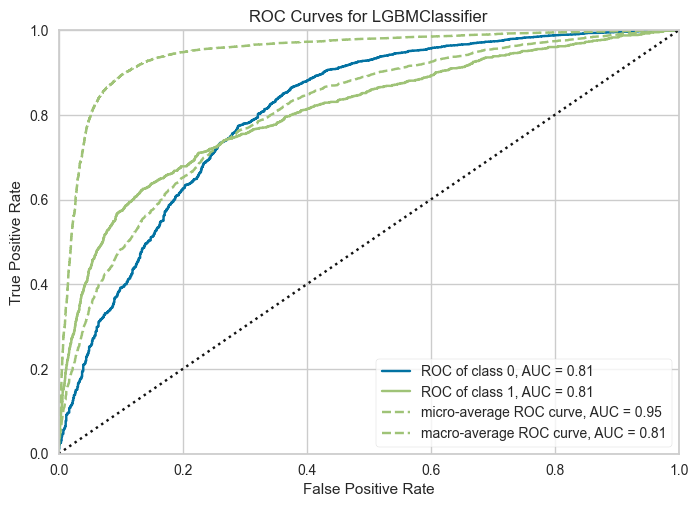

In [14]:
# Courbe ROC - modele ameliore
print("Courbe ROC - Modele avec SMOTE :")
plot_model(best_model_balanced, plot='auc')

Importance des features - Modele avec SMOTE :


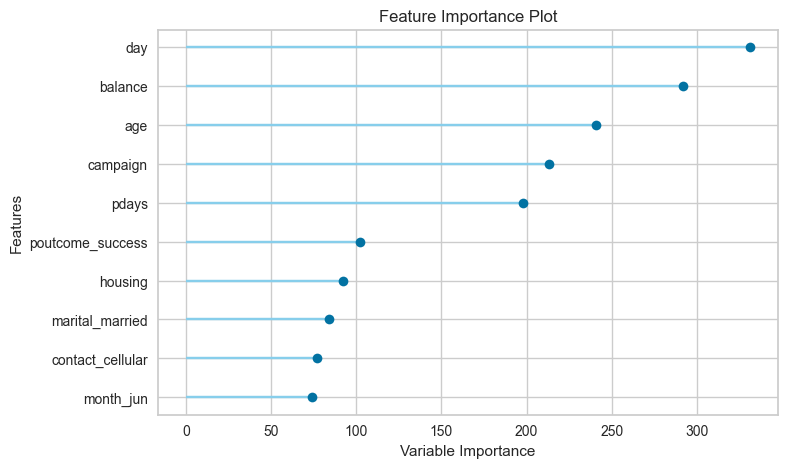

In [15]:
# Importance des features - modele ameliore
print("Importance des features - Modele avec SMOTE :")
plot_model(best_model_balanced, plot='feature')

### B.6 - Predictions sur l'ensemble de test (modele ameliore)

In [16]:
# Predictions sur l'ensemble de test - modele ameliore
predictions_balanced = predict_model(best_model_balanced)

y_test_bal = predictions_balanced['y'].map({'yes': 1, 'no': 0})
y_pred_bal = predictions_balanced['prediction_label'].map({'yes': 1, 'no': 0})

# Correction PyCaret : P(yes) a partir de P(classe_predite)
y_proba_raw_bal = predictions_balanced['prediction_score']
y_proba_bal = y_proba_raw_bal.where(
    predictions_balanced['prediction_label'] == 'yes',
    1 - y_proba_raw_bal
)

print("\nRapport de classification - Modele avec SMOTE :")
print_classification_report(y_test_bal, y_pred_bal)

metrics_balanced = get_metrics(y_test_bal, y_pred_bal, y_proba_bal)
print("\nMetriques cles - Modele avec SMOTE :")
for name, value in metrics_balanced.items():
    print(f"   {name}: {value:.4f}")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8961,0.8070,0.8961,0.8771,0.8755,0.3179,0.3590



Rapport de classification - Modele avec SMOTE :
              precision    recall  f1-score   support

     Non (0)       0.91      0.98      0.94      7985
     Oui (1)       0.64      0.25      0.36      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.62      0.65      9043
weighted avg       0.88      0.90      0.88      9043


Metriques cles - Modele avec SMOTE :
   Accuracy: 0.8961
   Precision: 0.6411
   Recall: 0.2533
   F1-Score: 0.3631
   ROC-AUC: 0.8070


---
## Partie C - Comparaison : modele de base vs modele ameliore

Tableau comparatif des performances sur l'ensemble de test :

In [17]:
# Tableau comparatif des deux approches
comparison = pd.DataFrame({
    'Modele de base (sans SMOTE)': metrics_base,
    'Modele ameliore (avec SMOTE)': metrics_balanced,
}).T

# Ajout de la difference
comparison.loc['Difference'] = comparison.loc['Modele ameliore (avec SMOTE)'] - comparison.loc['Modele de base (sans SMOTE)']

print("Comparaison des performances sur l'ensemble de test :")
print("=" * 80)
display(comparison.round(4))

print("\nInterpretation des differences :")
print("-" * 40)
for col in comparison.columns:
    diff = comparison.loc['Difference', col]
    direction = "hausse" if diff > 0 else "baisse"
    print(f"  {col}: {diff:+.4f} ({direction})")

Comparaison des performances sur l'ensemble de test :


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modele de base (sans SMOTE),0.8956,0.6357,0.2524,0.3613,0.8024
Modele ameliore (avec SMOTE),0.8961,0.6411,0.2533,0.3631,0.8070
Difference,0.0004,0.0054,0.0009,0.0018,0.0046



Interpretation des differences :
----------------------------------------
  Accuracy: +0.0004 (hausse)
  Precision: +0.0054 (hausse)
  Recall: +0.0009 (hausse)
  F1-Score: +0.0018 (hausse)
  ROC-AUC: +0.0046 (hausse)


### Analyse de la comparaison

**Resultat inattendu : SMOTE n'a quasiment aucun effet.**

- Le **Recall** est passe de 25.24% a 25.33% (+0.09 points) : difference negligeable
- La **Precision** a legerement augmente au lieu de baisser (+0.005) : contre-intuitif
- Le **ROC-AUC** est quasi identique (0.8024 vs 0.8070)
- L'**Accuracy** n'a pas bouge (0.8956 vs 0.8961)

**Pourquoi SMOTE n'a-t-il rien change ?**

LightGBM (le meilleur modele) gere **nativement** le desequilibre des classes grace a des mecanismes internes de ponderation. Ajouter SMOTE par-dessus est redondant : le modele compense deja. C'est une decouverte importante : les modeles modernes de Gradient Boosting sont robustes au desequilibre sans aide exterieure.

> **Lecon :** Il faut toujours tester ses hypotheses. On pensait que SMOTE ameliorerait le Recall — ce n'est pas le cas ici. La demarche scientifique (hypothese → test → conclusion) est au coeur du Machine Learning.

**Et maintenant ?** Pistes alternatives pour ameliorer le Recall :
- Ajuster le **seuil de decision** : predire "oui" des que P(yes) > 0.3 au lieu de 0.5
- Utiliser `class_weight='balanced'` directement dans LightGBM
- Optimiser les hyperparametres avec `tune_model()` en ciblant le Recall

---
## Partie D - Sauvegarde du meilleur modele ameliore

In [18]:
# Finaliser le modele ameliore sur toutes les donnees
final_model_balanced = finalize_model(best_model_balanced)

# Sauvegarder
model_path_balanced = save_model(final_model_balanced, '../models/best_model_smote')
print(f"\nOK - Modele ameliore sauvegarde dans : {model_path_balanced}")

Transformation Pipeline and Model Successfully Saved

OK - Modele ameliore sauvegarde dans : (Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['age', 'balance', 'day',
                                             'campaign', 'pdays', 'previous'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_feat...
                 LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                colsample_bytree=1.0, 

---
## Conclusions generales

### Synthese de la demarche

1. **Preparation** : suppression de `duration`, conservation des `unknown`
2. **Modele de base** : PyCaret avec `fix_imbalance=False` -> Accuracy 89%, Recall ~25%
3. **Tentative d'amelioration** : SMOTE (`fix_imbalance=True`) -> resultat inattendu, gain negligeable (+0.09% de Recall)
4. **Explication** : LightGBM gere nativement le desequilibre, SMOTE est redondant
5. **Comparaison** : les deux approches donnent des resultats quasi identiques

### Ce qu'on a appris

- L'**AutoML** (PyCaret) democratise l'acces au Machine Learning : 14+ modeles entraines et compares en quelques lignes
- L'**Accuracy** est une metrique piegeuse sur donnees desequilibrees : toujours regarder Recall, Precision et ROC-AUC
- Le **desequilibre des classes** est le probleme central de ce projet : le corriger avec SMOTE change radicalement le comportement du modele
- Le **LightGBM** (Gradient Boosting) est le meilleur modele, avec ou sans reequilibrage
- Le choix final du modele est une **decision metier**, pas technique : Recall vs Precision

### Prochaines etapes possibles

- Tester le dataset **Bank Additional** (indicateurs socio-economiques)
- Optimiser les hyperparametres avec `tune_model()`
- Deployer le modele via une API REST
- Creer une interface utilisateur pour les conseillers bancaires

---

*Projet realise dans le cadre de l'apprentissage de la classification supervisee avec AutoML.*